In [1]:
import pizprobe as piz
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

In [2]:
FILE = Path('./data/chip_label0003.ibw')

scan = piz.AsylumScan(FILE)

print(scan)

AsylumScan  chip_label0003.ibw
  Acquired     2026-09-24 12:13:37 PM · Vero · AR 21.09.77
  Mode         AC Mode, Closed Loop
  Scan         20.00 × 20.00 µm · 512 × 512 px · angle 0° · slow scan up
  Pixel size   39.14 × 39.14 nm   (sampling only; real lateral resolution is tip-limited)
  Timing       0.953 Hz line rate · 00:08:57 total
  Cantilever   drive 294.206 kHz (tuned resonance 294.346 kHz) · drive amplitude 0.260 V
  Feedback     setpoint 0.700 V / free air 0.932 V (ratio 0.75) · I gain 30 · P gain 0
  Calibration  InvOLS 100.0 nm/V · k 1.00 N/m   (!) software defaults: amplitudes in m are not calibrated
  Bias         tip 0 V · surface 0 V
  Channels     HeightRetrace [m] · AmplitudeRetrace [m] · PhaseRetrace [deg] · ZSensorRetrace [m]
  Correction   Asylum line flatten undone on: HeightRetrace, ZSensorRetrace


In [3]:
scan.channels

['HeightRetrace', 'AmplitudeRetrace', 'PhaseRetrace', 'ZSensorRetrace']

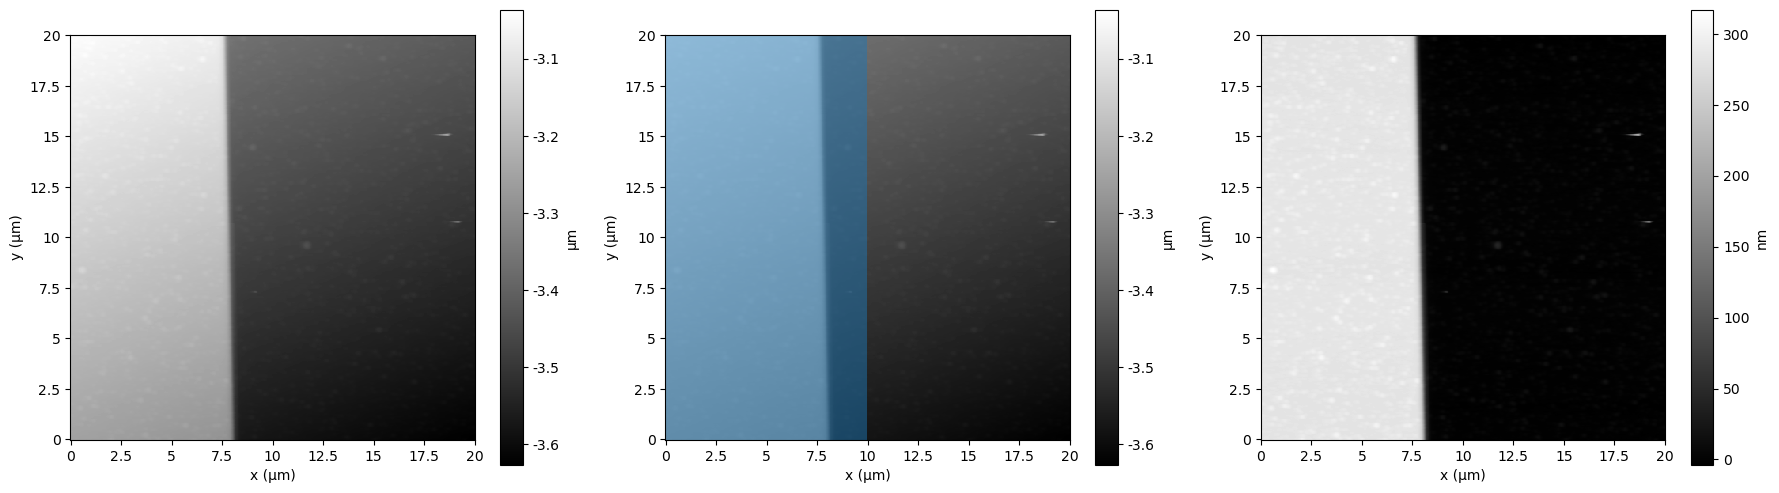

In [4]:
z = scan["ZSensorRetrace"].data
px = scan.pixel_size
region = piz.mask.rectangle(z.shape, x=(10e-6, 20e-6), y=(0, 20e-6), pixel_size=px)
features = ~region                      # True = left out: everything except the right half
levelled = piz.processing.plane_fit(z, mask=features, order=1)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
piz.plotting.image(z, ax=ax[0], pixel_size=px, cmap = 'gray')
piz.plotting.image(z, ax=ax[1], pixel_size=px, mask=features, cmap = 'gray')   # blue = left out of the fit
piz.plotting.image(levelled, ax=ax[2], pixel_size=px, cmap = 'gray')
fig.tight_layout()

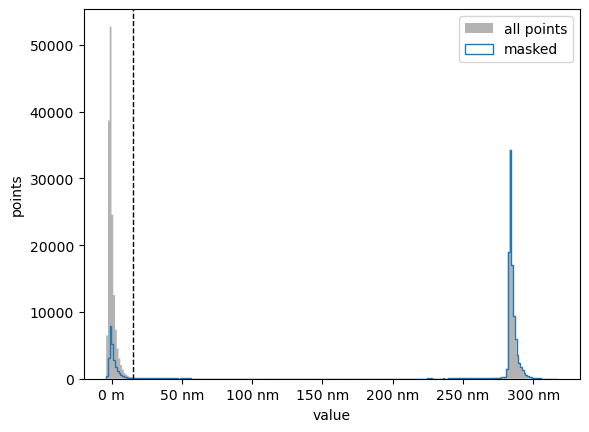

In [5]:
t = 15e-9
fig, ax = piz.plotting.histogram(levelled, mask = features, thresholds = [t])
# ax.set_yscale('log')

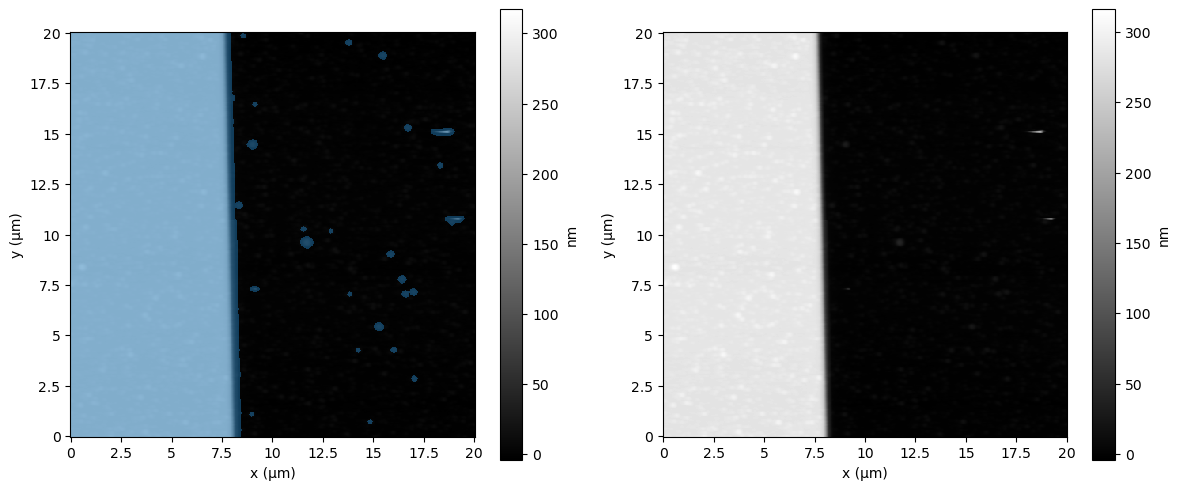

In [6]:
features2 = piz.mask.threshold(levelled, above=t)       # True = left out
features2 = piz.mask.grow(features2, pixels = 3)
levelled2 = piz.processing.plane_fit(z, mask=features2)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
piz.plotting.image(levelled, ax=ax[0], pixel_size=px, mask=features2, cmap = 'gray')   # check what is left out
piz.plotting.image(levelled2, ax=ax[1], pixel_size=px, cmap = 'gray')
fig.tight_layout()

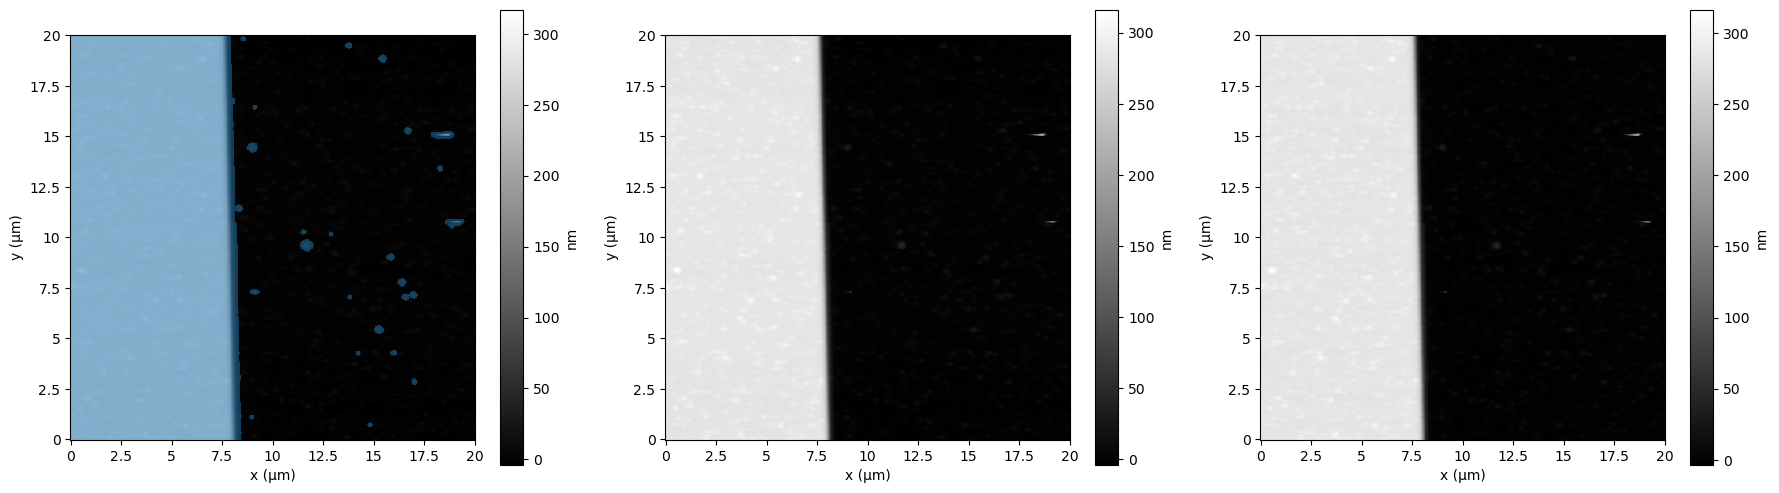

In [7]:
flattened = piz.processing.line_flatten(levelled2, mask = features2)   # plane first, then line offsets
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
piz.plotting.image(levelled, ax=ax[0], pixel_size=px, mask=features2, cmap = 'gray')   # check what is left out
piz.plotting.image(levelled2, ax=ax[1], pixel_size=px, cmap = 'gray')
piz.plotting.image(flattened, ax=ax[2], pixel_size=px, cmap = 'gray')
fig.tight_layout()

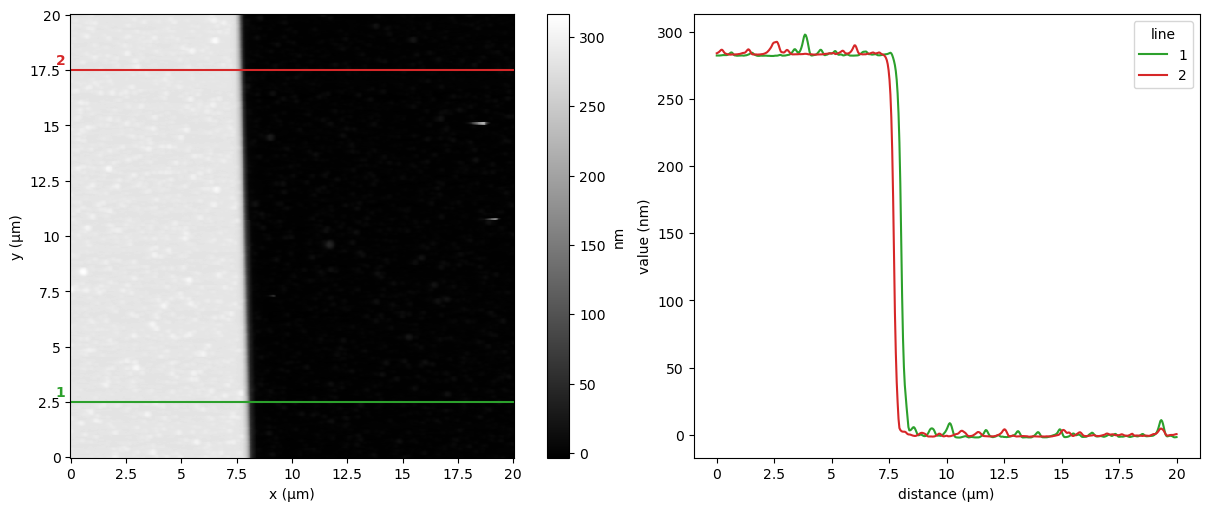

In [8]:
x_end = (z.shape[1] - 1) * px[0]           # centre of the last column (20 µm here)
cuts = [piz.analysis.profile(flattened, (0, y), (x_end, y), pixel_size=px) for y in (2.5e-6, 17.5e-6)]

fig, (ax_image, ax_profile) = piz.plotting.profiles(flattened, cuts, pixel_size=px, cmap='gray')

Text(0, 0.5, 'median floor height (nm)')

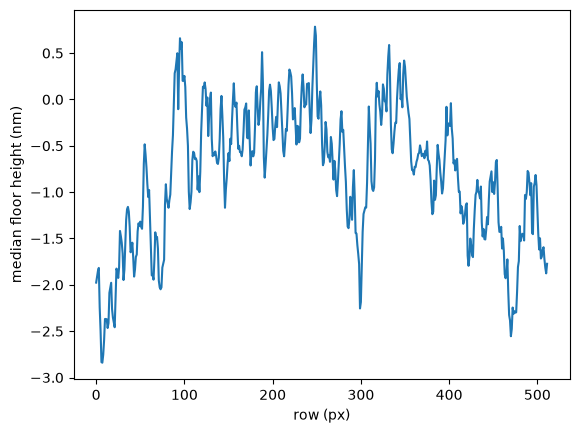

In [32]:
floor = np.where(features2, np.nan, levelled2)     # hide masked points
line_level = np.nanmedian(floor, axis=1)           # one value per scan line (row)

fig, ax = plt.subplots()
ax.plot(line_level * 1e9)
ax.set_xlabel("row (px)")
ax.set_ylabel("median floor height (nm)")